In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("zomato_clean.csv")
df.head(2)

,URL,ADDRESS,NAME,ONLINE_ORDER,BOOK_TABLE,RATE,VOTES,PHONE,LOCATION,REST_TYPE,DISH_LIKED,CUISINES,APPROX_COST_FOR_TWO_PEOPLE,REVIEWS_LIST,MENU_ITEM,LISTED_IN_TYPE,LISTED_IN_CITY,PRIMARY_REST_TYPE,PRIMARY_CUISINE,LOCATION_CLEAN
0,https://www.zomato.com/bangalore/sapnas-kitche...,"644, 4th 'C' Cross, OMBR Layout, Banaswadi, Ba...",Sapna's Kitchen,False,False,NaN,0,+91 9008501407\r\n+91 8095601114,Banaswadi,Quick Bites,NaN,"Chinese, North Indian, South Indian",400.0,NaN,NaN,Delivery,Kammanahalli,Quick Bites,Chinese,Banaswadi
1,https://www.zomato.com/bangalore/utsava-grand-...,"235, SC Road, Anand Rao Circle, Gandhi Nagar, ...",Utsava Grand,False,False,3.6,14,+91 8971076662,Majestic,Quick Bites,NaN,"South Indian, North Indian, Chinese",300.0,"[('Rated 5.0', 'RATED\n We were 6 of us from ...",NaN,Dine-out,Rajajinagar,Quick Bites,South Indian,Majestic


In [3]:
df['ONLINE_ORDER'] = df['ONLINE_ORDER'].astype(int)
df['BOOK_TABLE'] = df['BOOK_TABLE'].astype(int)

In [4]:
# Null Count
(df.isnull().sum() / len(df))*100

URL                            0.000000
ADDRESS                        0.000000
NAME                           0.000000
ONLINE_ORDER                   0.000000
BOOK_TABLE                     0.000000
RATE                          24.237829
VOTES                          0.000000
PHONE                          2.474062
LOCATION                       0.087789
REST_TYPE                      0.526736
DISH_LIKED                    62.801277
CUISINES                       0.191540
APPROX_COST_FOR_TWO_PEOPLE     0.766161
REVIEWS_LIST                  19.752594
MENU_ITEM                     78.355946
LISTED_IN_TYPE                 0.000000
LISTED_IN_CITY                 0.000000
PRIMARY_REST_TYPE              0.526736
PRIMARY_CUISINE                0.191540
LOCATION_CLEAN                 0.087789
dtype: float64

In [5]:
df=df.drop(columns=['LOCATION','LISTED_IN_CITY','PHONE','MENU_ITEM'])
#'REST_TYPE','CUISINES'

In [6]:
missing_pct = df.isnull().sum() / len(df) * 100
cols_under_1pct = missing_pct[(missing_pct > 0) & (missing_pct < 1)].index
cols_under_1pct

Index(['REST_TYPE', 'CUISINES', 'APPROX_COST_FOR_TWO_PEOPLE',
       'PRIMARY_REST_TYPE', 'PRIMARY_CUISINE', 'LOCATION_CLEAN'],
      dtype='object')

In [7]:
null_col=['REST_TYPE', 'CUISINES', 'APPROX_COST_FOR_TWO_PEOPLE','PRIMARY_REST_TYPE', 'PRIMARY_CUISINE', 'LOCATION_CLEAN']

In [8]:
df=df.dropna(subset=null_col)

In [9]:
df.isnull().sum()/len(df)*100

URL                            0.000000
ADDRESS                        0.000000
NAME                           0.000000
ONLINE_ORDER                   0.000000
BOOK_TABLE                     0.000000
RATE                          24.082458
VOTES                          0.000000
REST_TYPE                      0.000000
DISH_LIKED                    62.667745
CUISINES                       0.000000
APPROX_COST_FOR_TWO_PEOPLE     0.000000
REVIEWS_LIST                  19.636217
LISTED_IN_TYPE                 0.000000
PRIMARY_REST_TYPE              0.000000
PRIMARY_CUISINE                0.000000
LOCATION_CLEAN                 0.000000
dtype: float64

In [10]:
df.columns

Index(['URL', 'ADDRESS', 'NAME', 'ONLINE_ORDER', 'BOOK_TABLE', 'RATE', 'VOTES',
       'REST_TYPE', 'DISH_LIKED', 'CUISINES', 'APPROX_COST_FOR_TWO_PEOPLE',
       'REVIEWS_LIST', 'LISTED_IN_TYPE', 'PRIMARY_REST_TYPE',
       'PRIMARY_CUISINE', 'LOCATION_CLEAN'],
      dtype='object')

In [11]:
# create a dataframe which has no null count except "rate" to predict the missing RATE (24%)
nn_df=df[['URL', 'ADDRESS', 'NAME','ONLINE_ORDER', 'BOOK_TABLE', 'VOTES','DISH_LIKED','APPROX_COST_FOR_TWO_PEOPLE','REVIEWS_LIST','LISTED_IN_TYPE','REST_TYPE', 'PRIMARY_REST_TYPE',
 'CUISINES','PRIMARY_CUISINE', 'LOCATION_CLEAN', 'RATE']]

>In nn_df retreive only rate with non null rows to use it to create ML model then plug the
ML model to null values in orginal df

In [12]:
nn_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12370 entries, 0 to 12529
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   URL                         12370 non-null  object 
 1   ADDRESS                     12370 non-null  object 
 2   NAME                        12370 non-null  object 
 3   ONLINE_ORDER                12370 non-null  int64  
 4   BOOK_TABLE                  12370 non-null  int64  
 5   VOTES                       12370 non-null  int64  
 6   DISH_LIKED                  4618 non-null   object 
 7   APPROX_COST_FOR_TWO_PEOPLE  12370 non-null  float64
 8   REVIEWS_LIST                9941 non-null   object 
 9   LISTED_IN_TYPE              12370 non-null  object 
 10  REST_TYPE                   12370 non-null  object 
 11  PRIMARY_REST_TYPE           12370 non-null  object 
 12  CUISINES                    12370 non-null  object 
 13  PRIMARY_CUISINE             12370 no

In [13]:
(nn_df.isnull().sum()/len(df))*100

URL                            0.000000
ADDRESS                        0.000000
NAME                           0.000000
ONLINE_ORDER                   0.000000
BOOK_TABLE                     0.000000
VOTES                          0.000000
DISH_LIKED                    62.667745
APPROX_COST_FOR_TWO_PEOPLE     0.000000
REVIEWS_LIST                  19.636217
LISTED_IN_TYPE                 0.000000
REST_TYPE                      0.000000
PRIMARY_REST_TYPE              0.000000
CUISINES                       0.000000
PRIMARY_CUISINE                0.000000
LOCATION_CLEAN                 0.000000
RATE                          24.082458
dtype: float64

In [14]:
ml_df=nn_df[nn_df['RATE'].notnull()]
ml_df=ml_df.drop(columns=['REST_TYPE','CUISINES','DISH_LIKED','REVIEWS_LIST']).copy()
ml_df.isnull().sum()

URL                           0
ADDRESS                       0
NAME                          0
ONLINE_ORDER                  0
BOOK_TABLE                    0
VOTES                         0
APPROX_COST_FOR_TWO_PEOPLE    0
LISTED_IN_TYPE                0
PRIMARY_REST_TYPE             0
PRIMARY_CUISINE               0
LOCATION_CLEAN                0
RATE                          0
dtype: int64

----------------
Notes
* We'll use ml_df for ML Model
* Then plug ML model to df with RATE null columns

In [15]:
# outliers

In [16]:
def outlier_summary(ml_df):
    numeric_cols = ml_df.select_dtypes(include='number').columns
    summary = []
    
    for col in numeric_cols:
        Q1 = ml_df[col].quantile(0.05)
        Q3 = ml_df[col].quantile(0.95)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_count = ((ml_df[col] < lower) | (ml_df[col] > upper)).sum()
        
        summary.append({
            'column': col,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'lower_bound': lower,
            'upper_bound': upper,
            'outlier_count': outlier_count,
            'outlier_pct': round(outlier_count / len(ml_df) * 100, 2)
        })
    
    return pd.DataFrame(summary).sort_values('outlier_count', ascending=False)

outlier_summary(ml_df)

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_pct
2,VOTES,5.0,1016.5,1011.5,-1512.25,2533.75,131,1.39
3,APPROX_COST_FOR_TWO_PEOPLE,150.0,1400.0,1250.0,-1725.00,3275.00,20,0.21
0,ONLINE_ORDER,0.0,1.0,1.0,-1.50,2.50,0,0.00
1,BOOK_TABLE,0.0,1.0,1.0,-1.50,2.50,0,0.00
4,RATE,2.9,4.3,1.4,0.80,6.40,0,0.00


In [17]:
num_col=ml_df.select_dtypes(include='number').columns
cat_col=ml_df.select_dtypes(exclude='number').columns
print(num_col)
print(cat_col)

Index(['ONLINE_ORDER', 'BOOK_TABLE', 'VOTES', 'APPROX_COST_FOR_TWO_PEOPLE',
       'RATE'],
      dtype='object')
Index(['URL', 'ADDRESS', 'NAME', 'LISTED_IN_TYPE', 'PRIMARY_REST_TYPE',
       'PRIMARY_CUISINE', 'LOCATION_CLEAN'],
      dtype='object')


In [18]:
for i in cat_col:
    print(i)
    print(ml_df[i].value_counts())
    print("\n")

URL
URL
https://www.zomato.com/bangalore/families-food-court-hsr?context=eyJzZSI6eyJlIjpbIjUxMTc2IiwiNTM5MTAiLCIxODkyNzYzMCIsIjE4NTg4NjI1Iiw1Njk1MiwiNTc5NDEiLCIxODkyMjA4OSIsIjUyNTMyIiwiMTg4MTk3MTMiLCIxODk0NTQ0MSIsIjE4MjU0NTkxIiwiMTgzNjk4MTIiLCIxODE0MDc5NCIsIjU1Mjc1IiwiNTgxNjkiLCIxODI0NjQ4OCIsIjE4NDEyMTE2IiwiMTg2ODU0NTUiLCIxODgyNTQ3MyIsIjE4ODY1NTQ4IiwiMTg2ODQyMzciXSwidCI6IkRpbmUtT3V0IFJlc3RhdXJhbnRzIGluIEhTUiJ9fQ==                                                 1
https://www.zomato.com/bangalore/utsava-grand-majestic-bangalore?context=eyJzZSI6eyJlIjpbIjE4OTE5NDUzIiwiNTAxMDciLCIxODU3MjA3MSIsIjE4NjYwMTkyIiwxODY4OTEzMCwiMTg1Njc4NzAiLCIxODY2ODgyNSIsIjU0MjY5IiwiMTgzNjk4MjEiLCIxODQxMjExNSIsIjE4Njg4NTU2IiwiMTg4NzEwMzEiLCI1MjcxMSIsIjE4NzE1MzQzIiwiNTQzMzgiLCI1MjM2MSIsIjUzNTEzIiwiMTg2NjIxMjIiLCIxODI2MzI1NyIsIjU1NjkyIiwiMTg0MTk4MzAiXSwidCI6IkRpbmUtT3V0IFJlc3RhdXJhbnRzIGluIFJhamFqaW5hZ2FyIn19                                 1
https://www.zomato.com/bangalore/eat-fit-1-indiranagar-bangalore?context

In [19]:
# after clipping
for i in num_col:
     Q1 = ml_df[i].quantile(0.05)
     Q3 = ml_df[i].quantile(0.95)
     IQR = Q3 - Q1
     lower = Q1 - 1.5 * IQR
     upper = Q3 + 1.5 * IQR
     ml_df[i]=ml_df[i].clip(lower,upper).astype(float)

In [20]:
# after clipping
outlier_summary(ml_df)

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_pct
0,ONLINE_ORDER,0.0,1.0,1.0,-1.50,2.50,0,0.0
1,BOOK_TABLE,0.0,1.0,1.0,-1.50,2.50,0,0.0
2,VOTES,5.0,1016.5,1011.5,-1512.25,2533.75,0,0.0
3,APPROX_COST_FOR_TWO_PEOPLE,150.0,1400.0,1250.0,-1725.00,3275.00,0,0.0
4,RATE,2.9,4.3,1.4,0.80,6.40,0,0.0


In [21]:
from sklearn.model_selection import train_test_split

In [22]:
ml_df.head(2)

,URL,ADDRESS,NAME,ONLINE_ORDER,BOOK_TABLE,VOTES,APPROX_COST_FOR_TWO_PEOPLE,LISTED_IN_TYPE,PRIMARY_REST_TYPE,PRIMARY_CUISINE,LOCATION_CLEAN,RATE
1,https://www.zomato.com/bangalore/utsava-grand-...,"235, SC Road, Anand Rao Circle, Gandhi Nagar, ...",Utsava Grand,0.0,0.0,14.0,300.0,Dine-out,Quick Bites,South Indian,Majestic,3.6
2,https://www.zomato.com/bangalore/eat-fit-1-ind...,"2981, 12th Main Road, HAL 2nd Stage, Indiranag...",eat.fit,1.0,1.0,44.0,300.0,Dine-out,Quick Bites,Healthy Food,Indiranagar,3.9


In [23]:
ml_df.columns

Index(['URL', 'ADDRESS', 'NAME', 'ONLINE_ORDER', 'BOOK_TABLE', 'VOTES',
       'APPROX_COST_FOR_TWO_PEOPLE', 'LISTED_IN_TYPE', 'PRIMARY_REST_TYPE',
       'PRIMARY_CUISINE', 'LOCATION_CLEAN', 'RATE'],
      dtype='object')

In [24]:
#Split Data

In [25]:
X=ml_df[['ONLINE_ORDER', 'BOOK_TABLE','VOTES',
       'APPROX_COST_FOR_TWO_PEOPLE', 'LISTED_IN_TYPE',
       'PRIMARY_REST_TYPE', 'PRIMARY_CUISINE', 'LOCATION_CLEAN']]
y=ml_df[['RATE']]

In [26]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=48)

In [27]:
#Encoding

In [28]:
#target encoding

In [29]:
from category_encoders import TargetEncoder

In [30]:
encod_cols = ['PRIMARY_REST_TYPE', 'PRIMARY_CUISINE', 'LOCATION_CLEAN', 'LISTED_IN_TYPE']

In [31]:
te=TargetEncoder(cols=encod_cols)
Xtrain[encod_cols]=te.fit_transform(Xtrain[encod_cols],ytrain)
Xtest[encod_cols]=te.transform(Xtest[encod_cols])

In [32]:
#multi collinearity

In [33]:
# Calculate VIF
import statsmodels.formula.api as smf
def vif_cal(z):
    xvar=z
    xvar_names=z.columns
    for i in range(len(xvar_names)):
        y=xvar[xvar_names[i]]
        x=xvar[xvar_names.drop(xvar_names[i])]
        r2=smf.ols(formula="y~x",data=xvar).fit().rsquared
        vif=round( (1/(1-r2)) ,2)
        print(xvar_names[i], 'VIF = ' , vif)

In [34]:
Xtrain.head()

,ONLINE_ORDER,BOOK_TABLE,VOTES,APPROX_COST_FOR_TWO_PEOPLE,LISTED_IN_TYPE,PRIMARY_REST_TYPE,PRIMARY_CUISINE,LOCATION_CLEAN
2343,1.0,0.0,140.0,300.0,3.575196,3.509814,3.495721,3.649519
2861,1.0,0.0,236.0,750.0,3.575196,3.713529,3.550000,3.583053
10415,0.0,0.0,8.0,800.0,3.643342,3.713529,3.550000,3.606618
739,1.0,0.0,169.0,400.0,3.575196,3.559670,3.550000,3.649519
6269,0.0,0.0,198.0,700.0,3.643342,3.713529,3.550000,3.603380


In [35]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
model=LinearRegression()
rfe=RFE(estimator=model,n_features_to_select=5)
rf=rfe.fit(Xtrain,ytrain)

d2=pd.DataFrame(data={"feature": Xtrain.columns,"Ranking" : rf.ranking_})
d2.sort_values(by="Ranking",ascending=True)

,feature,Ranking
1,BOOK_TABLE,1
6,PRIMARY_CUISINE,1
5,PRIMARY_REST_TYPE,1
4,LISTED_IN_TYPE,1
7,LOCATION_CLEAN,1
0,ONLINE_ORDER,2
2,VOTES,3
3,APPROX_COST_FOR_TWO_PEOPLE,4


In [36]:
Xtrain.columns

Index(['ONLINE_ORDER', 'BOOK_TABLE', 'VOTES', 'APPROX_COST_FOR_TWO_PEOPLE',
       'LISTED_IN_TYPE', 'PRIMARY_REST_TYPE', 'PRIMARY_CUISINE',
       'LOCATION_CLEAN'],
      dtype='object')

In [37]:
vif_cal(z=Xtrain[['ONLINE_ORDER', 'BOOK_TABLE', 'VOTES', 'APPROX_COST_FOR_TWO_PEOPLE',
       'LISTED_IN_TYPE', 'PRIMARY_REST_TYPE', 'PRIMARY_CUISINE',
       'LOCATION_CLEAN']])

ONLINE_ORDER VIF =  1.1
BOOK_TABLE VIF =  1.79
VOTES VIF =  1.42
APPROX_COST_FOR_TWO_PEOPLE VIF =  2.37
LISTED_IN_TYPE VIF =  1.32
PRIMARY_REST_TYPE VIF =  2.08
PRIMARY_CUISINE VIF =  1.32
LOCATION_CLEAN VIF =  1.1


In [38]:
#model

In [39]:
from xgboost import XGBRegressor
import sklearn.metrics as metrics

In [40]:
m1 = XGBRegressor(random_state=42).fit(Xtrain,ytrain)

In [41]:
train_pred1=m1.predict(Xtrain)
test_pred1=m1.predict(Xtest)

In [42]:
print("\033[32mModel 1: XGBRegressor \033[0m")
print("---------------------")
print("Train R-square Score")
print(metrics.r2_score(ytrain,train_pred1))
print("---------------------")
print("Test R-square Score")
print(metrics.r2_score(ytest,test_pred1))

Model 1: XGBRegressor 
---------------------
Train R-square Score
0.7723974585533142
---------------------
Test R-square Score
0.40893983840942383


In [43]:
def rmspe(ytrue,ypred):
    ytrue=np.array(ytrue)
    ypred=np.array(ypred)
    return round(np.sqrt( np.mean( ( (ytrue-ypred)/(ytrue) )**2 ) ) *100,2)

In [44]:
print("\033[32mModel 1: XGBRegressor \033[0m")
print("---------------------")
print("RMSPE on Train Data : ",rmspe(ytrain,train_pred1),"%")
print("RMSPE on Test Data : ",rmspe(ytest,test_pred1),"%")

Model 1: XGBRegressor 
---------------------
RMSPE on Train Data :  16.07 %
RMSPE on Test Data :  16.17 %


In [45]:
from sklearn.model_selection import GridSearchCV

In [46]:
params={
    'n_estimators': [150,300, 500],
    'max_depth': [4, 6,8,10],
    'learning_rate': [0.01, 0.05,0.1],
}

In [47]:
m2 = XGBRegressor( n_estimators=600,
    learning_rate=0.01,
    max_depth=4,random_state=42).fit(Xtrain,ytrain)

In [48]:
train_pred2=m2.predict(Xtrain)
test_pred2=m2.predict(Xtest)

In [49]:
print("\033[32mModel 2: XGBRegressor \033[0m")
print("---------------------")
print("Train R-square Score")
print(metrics.r2_score(ytrain,train_pred2))
print("---------------------")
print("Test R-square Score")
print(metrics.r2_score(ytest,test_pred2))

Model 2: XGBRegressor 
---------------------
Train R-square Score
0.49574899673461914
---------------------
Test R-square Score
0.43531519174575806


In [50]:
print("\033[32mModel 2: XGBRegressor \033[0m")
print("---------------------")
print("RMSPE on Train Data : ",rmspe(ytrain,train_pred2),"%")
print("RMSPE on Test Data : ",rmspe(ytest,test_pred2),"%")

Model 2: XGBRegressor 
---------------------
RMSPE on Train Data :  15.21 %
RMSPE on Test Data :  15.59 %


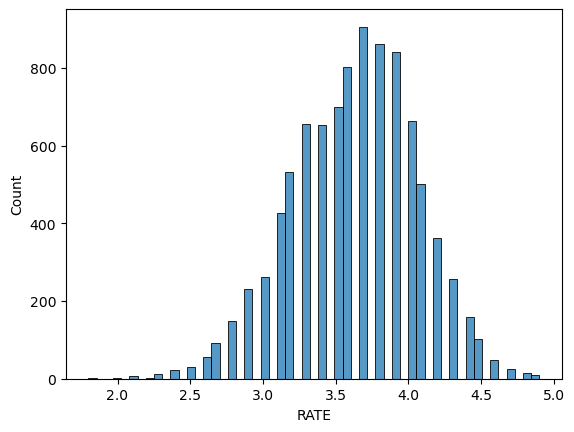

In [51]:
sns.histplot(ml_df['RATE'])
plt.show()

In [52]:
y_train_log = np.log1p(ytrain)   # log(1 + y)
y_test_log  = np.log1p(ytest)

In [53]:
m3 = XGBRegressor(
    n_estimators=600,
    learning_rate=0.01,
    max_depth=4,
    random_state=42
   
).fit(Xtrain,y_train_log)

In [54]:
train_pred3=m3.predict(Xtrain)
test_pred3=m3.predict(Xtest)

In [55]:
print("\033[32mModel 3: XGBRegressor \033[0m")
print("---------------------")
print("Train R-square Score")
print(metrics.r2_score(y_train_log ,train_pred3))
print("---------------------")
print("Test R-square Score")
print(metrics.r2_score(y_test_log,test_pred3))

Model 3: XGBRegressor 
---------------------
Train R-square Score
0.4613255262374878
---------------------
Test R-square Score
0.3938589096069336


In [56]:
print("\033[32mModel 3: XGBRegressor \033[0m")
print("---------------------")
print("RMSPE on Train Data : ",rmspe(y_train_log,train_pred3),"%")
print("RMSPE on Test Data : ",rmspe(y_test_log,test_pred3),"%")

Model 3: XGBRegressor 
---------------------
RMSPE on Train Data :  7.6 %
RMSPE on Test Data :  7.77 %


In [57]:
# Check model stability using Cross Valdiation Score
from sklearn.model_selection import cross_val_score
model=XGBRegressor(n_estimators=600,learning_rate=0.01,max_depth=4,random_state=42)
-cross_val_score(model,Xtrain,y_train_log,cv=5,scoring="neg_mean_squared_error")

array([0.00589029, 0.0052859 , 0.00506754, 0.00473431, 0.00512465])

**Model 3  has great RMPSE and performs stable in all folds**

In [58]:
ml_df.isnull().sum()

URL                           0
ADDRESS                       0
NAME                          0
ONLINE_ORDER                  0
BOOK_TABLE                    0
VOTES                         0
APPROX_COST_FOR_TWO_PEOPLE    0
LISTED_IN_TYPE                0
PRIMARY_REST_TYPE             0
PRIMARY_CUISINE               0
LOCATION_CLEAN                0
RATE                          0
dtype: int64

In [59]:
# We'll train the model in ml_df in which Rate column has 0 null value

In [60]:
Xtrain.columns

Index(['ONLINE_ORDER', 'BOOK_TABLE', 'VOTES', 'APPROX_COST_FOR_TWO_PEOPLE',
       'LISTED_IN_TYPE', 'PRIMARY_REST_TYPE', 'PRIMARY_CUISINE',
       'LOCATION_CLEAN'],
      dtype='object')

In [61]:
final_train_df=ml_df[['ONLINE_ORDER', 'BOOK_TABLE', 'VOTES', 'APPROX_COST_FOR_TWO_PEOPLE',
       'LISTED_IN_TYPE', 'PRIMARY_REST_TYPE', 'PRIMARY_CUISINE',
       'LOCATION_CLEAN','RATE']]

In [62]:
final_train_df.head()

,ONLINE_ORDER,BOOK_TABLE,VOTES,APPROX_COST_FOR_TWO_PEOPLE,LISTED_IN_TYPE,PRIMARY_REST_TYPE,PRIMARY_CUISINE,LOCATION_CLEAN,RATE
1,0.0,0.0,14.0,300.0,Dine-out,Quick Bites,South Indian,Majestic,3.6
2,1.0,1.0,44.0,300.0,Dine-out,Quick Bites,Healthy Food,Indiranagar,3.9
3,1.0,0.0,56.0,600.0,Delivery,Quick Bites,American,Electronic City,3.9
4,0.0,0.0,1926.0,850.0,Dine-out,Casual Dining,Andhra,Indiranagar,4.2
5,1.0,0.0,4.0,250.0,Delivery,Beverage Shop,Beverages,BTM,3.3


In [63]:
X_final_train=final_train_df.drop(columns=['RATE'])
y_final_train=final_train_df['RATE']

In [64]:
X_final_train.head(3)

,ONLINE_ORDER,BOOK_TABLE,VOTES,APPROX_COST_FOR_TWO_PEOPLE,LISTED_IN_TYPE,PRIMARY_REST_TYPE,PRIMARY_CUISINE,LOCATION_CLEAN
1,0.0,0.0,14.0,300.0,Dine-out,Quick Bites,South Indian,Majestic
2,1.0,1.0,44.0,300.0,Dine-out,Quick Bites,Healthy Food,Indiranagar
3,1.0,0.0,56.0,600.0,Delivery,Quick Bites,American,Electronic City


In [65]:
y_final_train.head(3)

1    3.6
2    3.9
3    3.9
Name: RATE, dtype: float64

In [66]:
te2=TargetEncoder(cols=encod_cols)
X_final_train[encod_cols]=te2.fit_transform(X_final_train[encod_cols],y_final_train)

In [67]:
y_final_train_log = np.log1p(y_final_train)# log(1 + y)

In [68]:
final_model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.01,
    max_depth=4,
    random_state=42
   
).fit(X_final_train,y_final_train_log)

In [69]:
train_pred_final=final_model.predict(X_final_train)

In [70]:
print("RMPSE of Final Model TrainData =",rmspe(y_final_train_log,train_pred_final),"%")

RMPSE of Final Model TrainData = 5.03 %


In [71]:
df.isnull().sum()/len(df)*100

URL                            0.000000
ADDRESS                        0.000000
NAME                           0.000000
ONLINE_ORDER                   0.000000
BOOK_TABLE                     0.000000
RATE                          24.082458
VOTES                          0.000000
REST_TYPE                      0.000000
DISH_LIKED                    62.667745
CUISINES                       0.000000
APPROX_COST_FOR_TWO_PEOPLE     0.000000
REVIEWS_LIST                  19.636217
LISTED_IN_TYPE                 0.000000
PRIMARY_REST_TYPE              0.000000
PRIMARY_CUISINE                0.000000
LOCATION_CLEAN                 0.000000
dtype: float64

In [72]:
final_pred_df=df[( df['RATE'].isnull() )].copy()

In [73]:
print("Pred DF Length :",len(final_pred_df))
print("--"*20)
print(final_pred_df.isnull().sum())

Pred DF Length : 2979
----------------------------------------
URL                              0
ADDRESS                          0
NAME                             0
ONLINE_ORDER                     0
BOOK_TABLE                       0
RATE                          2979
VOTES                            0
REST_TYPE                        0
DISH_LIKED                    2950
CUISINES                         0
APPROX_COST_FOR_TWO_PEOPLE       0
REVIEWS_LIST                  2088
LISTED_IN_TYPE                   0
PRIMARY_REST_TYPE                0
PRIMARY_CUISINE                  0
LOCATION_CLEAN                   0
dtype: int64


In [74]:
final_pred_df.drop(columns=["RATE"],inplace=True)

In [75]:
final_pred_df.head(2)

,URL,ADDRESS,NAME,ONLINE_ORDER,BOOK_TABLE,VOTES,REST_TYPE,DISH_LIKED,CUISINES,APPROX_COST_FOR_TWO_PEOPLE,REVIEWS_LIST,LISTED_IN_TYPE,PRIMARY_REST_TYPE,PRIMARY_CUISINE,LOCATION_CLEAN
0,https://www.zomato.com/bangalore/sapnas-kitche...,"644, 4th 'C' Cross, OMBR Layout, Banaswadi, Ba...",Sapna's Kitchen,0,0,0,Quick Bites,NaN,"Chinese, North Indian, South Indian",400.0,NaN,Delivery,Quick Bites,Chinese,Banaswadi
6,https://www.zomato.com/bangalore/al-noor-resta...,"10/122, Ground Floor, Ghousia Complex, Near Ri...",Al-Noor Restaurant,1,0,0,Quick Bites,NaN,"Chinese, North Indian, Mughlai",400.0,"[('Rated 5.0', 'RATED\n It was good visiting ...",Dine-out,Quick Bites,Chinese,Nagawara


In [76]:
predict_df=final_pred_df[['ONLINE_ORDER', 'BOOK_TABLE', 'VOTES', 'APPROX_COST_FOR_TWO_PEOPLE',
       'LISTED_IN_TYPE', 'PRIMARY_REST_TYPE', 'PRIMARY_CUISINE',
       'LOCATION_CLEAN']].copy()

In [77]:
predict_df.head(3)

,ONLINE_ORDER,BOOK_TABLE,VOTES,APPROX_COST_FOR_TWO_PEOPLE,LISTED_IN_TYPE,PRIMARY_REST_TYPE,PRIMARY_CUISINE,LOCATION_CLEAN
0,0,0,0,400.0,Delivery,Quick Bites,Chinese,Banaswadi
6,1,0,0,400.0,Dine-out,Quick Bites,Chinese,Nagawara
7,0,0,0,250.0,Dine-out,Quick Bites,Biryani,Rajajinagar


In [78]:
#encode this for model prediction
predict_df[encod_cols]=te2.transform(predict_df[encod_cols])

In [79]:
predicted_rating_log1p = final_model.predict(predict_df)
print(predicted_rating_log1p)

[1.4750125 1.4762876 1.4787062 ... 1.496365  1.4791961 1.4833746]


In [80]:
# Convert predictions from log1p scale to original scale
final_predicted_rating = np.expm1(predicted_rating_log1p)

# Round to 2 decimal places
final_predicted_rating = np.round(final_predicted_rating, 2)

print(final_predicted_rating)

[3.37 3.38 3.39 ... 3.47 3.39 3.41]


In [81]:
final_pred_df["RATE"]=final_predicted_rating

In [82]:
final_pred_df.head(2)

,URL,ADDRESS,NAME,ONLINE_ORDER,BOOK_TABLE,VOTES,REST_TYPE,DISH_LIKED,CUISINES,APPROX_COST_FOR_TWO_PEOPLE,REVIEWS_LIST,LISTED_IN_TYPE,PRIMARY_REST_TYPE,PRIMARY_CUISINE,LOCATION_CLEAN,RATE
0,https://www.zomato.com/bangalore/sapnas-kitche...,"644, 4th 'C' Cross, OMBR Layout, Banaswadi, Ba...",Sapna's Kitchen,0,0,0,Quick Bites,NaN,"Chinese, North Indian, South Indian",400.0,NaN,Delivery,Quick Bites,Chinese,Banaswadi,3.37
6,https://www.zomato.com/bangalore/al-noor-resta...,"10/122, Ground Floor, Ghousia Complex, Near Ri...",Al-Noor Restaurant,1,0,0,Quick Bites,NaN,"Chinese, North Indian, Mughlai",400.0,"[('Rated 5.0', 'RATED\n It was good visiting ...",Dine-out,Quick Bites,Chinese,Nagawara,3.38


In [83]:
final_pred_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2979 entries, 0 to 12522
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   URL                         2979 non-null   object 
 1   ADDRESS                     2979 non-null   object 
 2   NAME                        2979 non-null   object 
 3   ONLINE_ORDER                2979 non-null   int64  
 4   BOOK_TABLE                  2979 non-null   int64  
 5   VOTES                       2979 non-null   int64  
 6   REST_TYPE                   2979 non-null   object 
 7   DISH_LIKED                  29 non-null     object 
 8   CUISINES                    2979 non-null   object 
 9   APPROX_COST_FOR_TWO_PEOPLE  2979 non-null   float64
 10  REVIEWS_LIST                891 non-null    object 
 11  LISTED_IN_TYPE              2979 non-null   object 
 12  PRIMARY_REST_TYPE           2979 non-null   object 
 13  PRIMARY_CUISINE             2979 non-

In [84]:
nn_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12370 entries, 0 to 12529
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   URL                         12370 non-null  object 
 1   ADDRESS                     12370 non-null  object 
 2   NAME                        12370 non-null  object 
 3   ONLINE_ORDER                12370 non-null  int64  
 4   BOOK_TABLE                  12370 non-null  int64  
 5   VOTES                       12370 non-null  int64  
 6   DISH_LIKED                  4618 non-null   object 
 7   APPROX_COST_FOR_TWO_PEOPLE  12370 non-null  float64
 8   REVIEWS_LIST                9941 non-null   object 
 9   LISTED_IN_TYPE              12370 non-null  object 
 10  REST_TYPE                   12370 non-null  object 
 11  PRIMARY_REST_TYPE           12370 non-null  object 
 12  CUISINES                    12370 non-null  object 
 13  PRIMARY_CUISINE             12370 no

In [85]:
rate_notnull_df=nn_df[(nn_df['RATE'].notnull())]

In [86]:
rate_notnull_df

,URL,ADDRESS,NAME,ONLINE_ORDER,BOOK_TABLE,VOTES,DISH_LIKED,APPROX_COST_FOR_TWO_PEOPLE,REVIEWS_LIST,LISTED_IN_TYPE,REST_TYPE,PRIMARY_REST_TYPE,CUISINES,PRIMARY_CUISINE,LOCATION_CLEAN,RATE
1,https://www.zomato.com/bangalore/utsava-grand-...,"235, SC Road, Anand Rao Circle, Gandhi Nagar, ...",Utsava Grand,0,0,14,NaN,300.0,"[('Rated 5.0', 'RATED\n We were 6 of us from ...",Dine-out,Quick Bites,Quick Bites,"South Indian, North Indian, Chinese",South Indian,Majestic,3.6
2,https://www.zomato.com/bangalore/eat-fit-1-ind...,"2981, 12th Main Road, HAL 2nd Stage, Indiranag...",eat.fit,1,1,44,NaN,300.0,"[('Rated 2.0', 'RATED\n All these days I like...",Dine-out,Quick Bites,Quick Bites,"Healthy Food, North Indian, Biryani, Continent...",Healthy Food,Indiranagar,3.9
3,https://www.zomato.com/bangalore/bib-breakfast...,"810, 2nd Floor, 10th Cross, Neeladri Nagar, Ab...",BIB - Breakfast in the Box,1,0,56,"Chicken Burger, Corn Sandwich, French Fries, V...",600.0,"[('Rated 2.0', 'RATED\n I ordered The Farmers...",Delivery,Quick Bites,Quick Bites,"American, Sandwich",American,Electronic City,3.9
4,https://www.zomato.com/bangalore/nagarjuna-ind...,"195, Double Road, Indiranagar, Bangalore",Nagarjuna,0,0,1926,"Mutton Biryani, Andhra Style Biryani, Andhra M...",850.0,"[('Rated 1.0', ""RATED\n This place has good m...",Dine-out,Casual Dining,Casual Dining,"Andhra, Biryani",Andhra,Indiranagar,4.2
5,https://www.zomato.com/bangalore/lassi-pot-btm...,"2, Lassi Pot, 1st main road, maruthi nagar, BT...",Lassi Pot,1,0,4,NaN,250.0,"[('Rated 5.0', 'RATED\n D best lassi i ever h...",Delivery,Beverage Shop,Beverage Shop,Beverages,Beverages,BTM,3.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12525,https://www.zomato.com/bangalore/savi-sagar-ma...,"158/2, Near Natraj Theatre, S.C Road, Malleshw...",Savi Sagar,1,0,136,NaN,450.0,"[('Rated 3.0', 'RATED\n Visited for the first...",Dine-out,Casual Dining,Casual Dining,"North Indian, South Indian, Chinese, Street Fo...",North Indian,Malleshwaram,3.7
12526,https://www.zomato.com/bangalore/rajwadi-marat...,"595, Ground Floor, Kundalahalli, Varthur Hobli...",Rajwadi,0,0,10,NaN,500.0,"[('Rated 2.0', 'RATED\n Guess this is the fir...",Dine-out,Quick Bites,Quick Bites,"North Indian, Street Food",North Indian,Brookefield,3.6
12527,https://www.zomato.com/bangalore/wild-range-re...,"87, Nehru Road, Kammanahalli, Bangalore",Wild Range Restaurant,1,0,45,NaN,600.0,"[('Rated 5.0', ""RATED\n I order one hot nd so...",Dine-out,Casual Dining,Casual Dining,"North Indian, Chinese",North Indian,Kammanahalli,3.8
12528,https://www.zomato.com/bangalore/sri-krishna-s...,"Opposite The Forum Mall, Koramangala 7th Block...",Sri Krishna Sagar,0,0,13,NaN,300.0,"[('Rated 4.0', ""RATED\n In the mood for authe...",Dine-out,Quick Bites,Quick Bites,South Indian,South Indian,Koramangala 7th Block,3.6


In [87]:
final_df=pd.concat([rate_notnull_df,final_pred_df],axis=0)

In [88]:
final_df['ONLINE_ORDER'] = final_df['ONLINE_ORDER'].astype(bool)
final_df['BOOK_TABLE']   = final_df['BOOK_TABLE'].astype(bool)

In [89]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12370 entries, 1 to 12522
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   URL                         12370 non-null  object 
 1   ADDRESS                     12370 non-null  object 
 2   NAME                        12370 non-null  object 
 3   ONLINE_ORDER                12370 non-null  bool   
 4   BOOK_TABLE                  12370 non-null  bool   
 5   VOTES                       12370 non-null  int64  
 6   DISH_LIKED                  4618 non-null   object 
 7   APPROX_COST_FOR_TWO_PEOPLE  12370 non-null  float64
 8   REVIEWS_LIST                9941 non-null   object 
 9   LISTED_IN_TYPE              12370 non-null  object 
 10  REST_TYPE                   12370 non-null  object 
 11  PRIMARY_REST_TYPE           12370 non-null  object 
 12  CUISINES                    12370 non-null  object 
 13  PRIMARY_CUISINE             12370 no

In [90]:
final_df.head(3)

,URL,ADDRESS,NAME,ONLINE_ORDER,BOOK_TABLE,VOTES,DISH_LIKED,APPROX_COST_FOR_TWO_PEOPLE,REVIEWS_LIST,LISTED_IN_TYPE,REST_TYPE,PRIMARY_REST_TYPE,CUISINES,PRIMARY_CUISINE,LOCATION_CLEAN,RATE
1,https://www.zomato.com/bangalore/utsava-grand-...,"235, SC Road, Anand Rao Circle, Gandhi Nagar, ...",Utsava Grand,False,False,14,NaN,300.0,"[('Rated 5.0', 'RATED\n We were 6 of us from ...",Dine-out,Quick Bites,Quick Bites,"South Indian, North Indian, Chinese",South Indian,Majestic,3.6
2,https://www.zomato.com/bangalore/eat-fit-1-ind...,"2981, 12th Main Road, HAL 2nd Stage, Indiranag...",eat.fit,True,True,44,NaN,300.0,"[('Rated 2.0', 'RATED\n All these days I like...",Dine-out,Quick Bites,Quick Bites,"Healthy Food, North Indian, Biryani, Continent...",Healthy Food,Indiranagar,3.9
3,https://www.zomato.com/bangalore/bib-breakfast...,"810, 2nd Floor, 10th Cross, Neeladri Nagar, Ab...",BIB - Breakfast in the Box,True,False,56,"Chicken Burger, Corn Sandwich, French Fries, V...",600.0,"[('Rated 2.0', 'RATED\n I ordered The Farmers...",Delivery,Quick Bites,Quick Bites,"American, Sandwich",American,Electronic City,3.9


In [92]:
final_df.to_csv(
    r"D:\Studies\DataScienceNAASCOM\AnalytixLabs Internship\Project 2\ZomatoFinalProject\Data_Zomato\final_df.csv",
    index=False
)